### How output depends on irradiance, cloud cover and season across plants?

In [87]:
# Environment check and shared imports for the whole notebook
import pandas as pd, glob, os 
from pandas.plotting import table 

import numpy as np, duckdb, matplotlib
import seaborn as sns
import matplotlib.pyplot as plt, pathlib, warnings
from scipy.stats import f_oneway
from ydata_profiling import ProfileReport
# from data_profiling import ProfileReport
warnings.filterwarnings('ignore')
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']: pathlib.Path(d).mkdir(parents=True, exist_ok=True)
np.random.seed(42); pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)

conn = duckdb.connect()

print('pandas', pd.__version__, '| duckdb', duckdb.__version__)

pandas 2.3.3 | duckdb 1.5.5


In [18]:
# Get m back as the dataframe from parquet
df = pd.read_parquet('data/processed/solar.parquet')

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
display(df.head())



Rows: 87,302
Columns: 10


,time,power,plant,site_id,cap_mw,GHI,DNI,cloud,temp,cf
0,2006-01-01 07:00:00,0.066667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,75,433,0,10.6,0.002477
1,2006-01-01 08:00:00,5.266667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,163,99,7,11.8,0.195666
2,2006-01-01 09:00:00,8.341667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,155,14,8,12.9,0.309907
3,2006-01-01 10:00:00,8.391667,Actual_33.65_-117.25_2006_DPV_,15,26.916667,217,21,7,14.1,0.311765
4,2006-01-01 11:00:00,7.733333,Actual_33.65_-117.25_2006_DPV_,15,26.916667,218,18,7,15.3,0.287307


### Add month and season and check season distribution

season,Autumn,Spring,Summer,Winter
plant,,,,
Actual_32.75_-115.45_2006_UPV_,1017,1167,1258,887
Actual_33.05_-116.85_2006_DPV_,1017,1175,1268,915
Actual_33.25_-114.85_2006_UPV_,1017,1167,1258,887
Actual_33.65_-117.25_2006_DPV_,1016,1177,1269,913
Actual_33.75_-116.15_2006_UPV_,1017,1177,1267,902
Actual_33.75_-116.25_2006_DPV_,1017,1177,1267,902
Actual_34.05_-117.15_2006_DPV_,1013,1179,1270,913
Actual_34.15_-117.25_2006_DPV_,1013,1179,1270,913
Actual_34.25_-117.65_2006_UPV_,1013,1179,1270,913


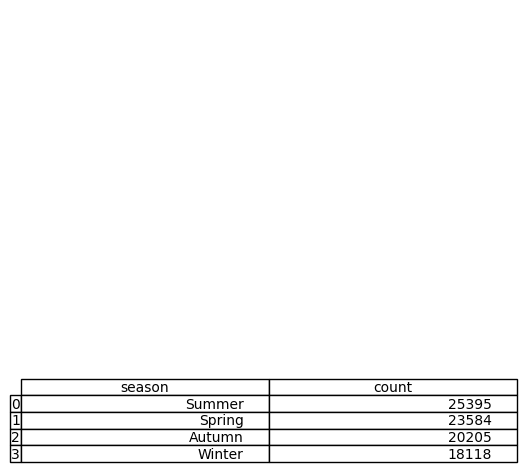

In [90]:
# add hour, month and season to the data frame
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# Check season value counts
ax = plt.subplot(111, frame_on=False) # no visible frame
ax.xaxis.set_visible(False)  # hide the x axis
ax.yaxis.set_visible(False)  # hide the y axis

table(ax, df['season'].value_counts().reset_index())

# Check distribution of season across plants
display(
    df.groupby(['plant', 'season'])
      .size()
      .unstack(fill_value=0)
)

- Summer's count is significantly higher than Winter by ~7000 
- Each season is distributed evenly across all 20 sampled plants

### Understand capacity factor

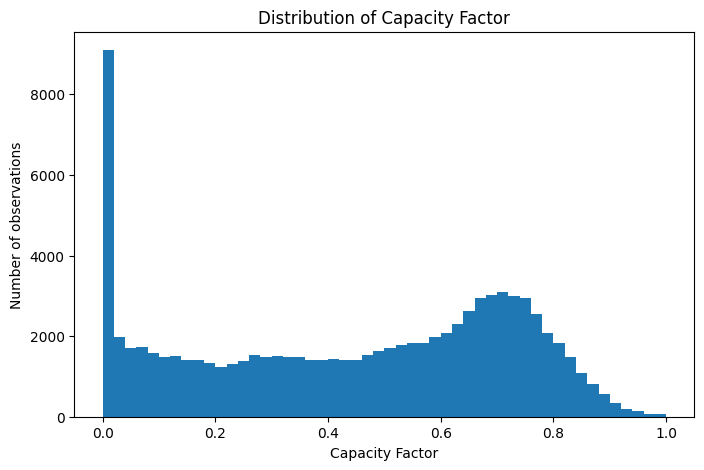

In [28]:
df['cf'].describe()

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['cf'], bins=50)
plt.xlabel('Capacity Factor')
plt.ylabel('Number of observations')
plt.title('Distribution of Capacity Factor')
plt.show()

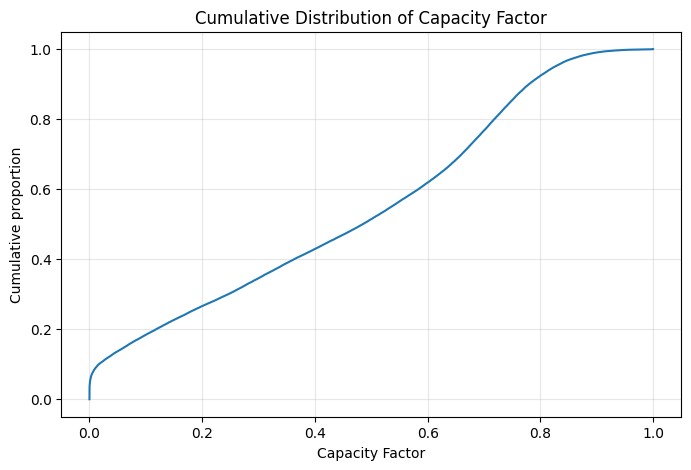

In [29]:
# ECDF (Empirical Cumulative Distribution Function)
cf_sorted = np.sort(df['cf'].dropna())
y = np.arange(1, len(cf_sorted) + 1) / len(cf_sorted)

plt.figure(figsize=(8, 5))

plt.plot(cf_sorted, y)

plt.xlabel('Capacity Factor')
plt.ylabel('Cumulative proportion')
plt.title('Cumulative Distribution of Capacity Factor')

plt.grid(alpha=0.3)

plt.show()

In [30]:
plant_cf = (
    df.groupby('plant')['cf']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .sort_values('mean')
)

display(plant_cf)

,count,mean,median,std,min,max
plant,,,,,,
Actual_37.95_-121.75_2006_DPV_,4376,0.368562,0.355807,0.266958,0.0,1.0
Actual_38.65_-121.25_2006_DPV_,4351,0.370234,0.352676,0.271827,0.0,1.0
Actual_37.95_-121.65_2006_DPV_,4376,0.370952,0.357172,0.271265,0.0,1.0
Actual_38.65_-121.05_2006_DPV_,4351,0.383664,0.364367,0.282103,0.0,1.0
Actual_34.55_-118.55_2006_UPV_,4377,0.390416,0.415773,0.262294,0.0,1.0
Actual_37.45_-121.95_2006_DPV_,4376,0.398278,0.381908,0.292708,0.0,1.0
Actual_34.15_-117.25_2006_DPV_,4375,0.403118,0.416543,0.272121,0.0,1.0
Actual_34.25_-117.65_2006_UPV_,4375,0.415217,0.439237,0.278776,0.0,1.0
Actual_34.05_-117.15_2006_DPV_,4375,0.415419,0.437194,0.278184,0.0,1.0


- Capacity factor seems to have a lot of very small values near 0 (indicated by the very tall bar in the histogram)
- The ECDF (Empirical Cumulative Distribution Function) shows that around 10% of all capacity factor values are 0 or near 0
- Some plants seem to perform better than others that could be related to its location or equipment, with the highest mean being 0.568 whereas the lowest at 0.369

### Check each attribute relationship with capacity factor

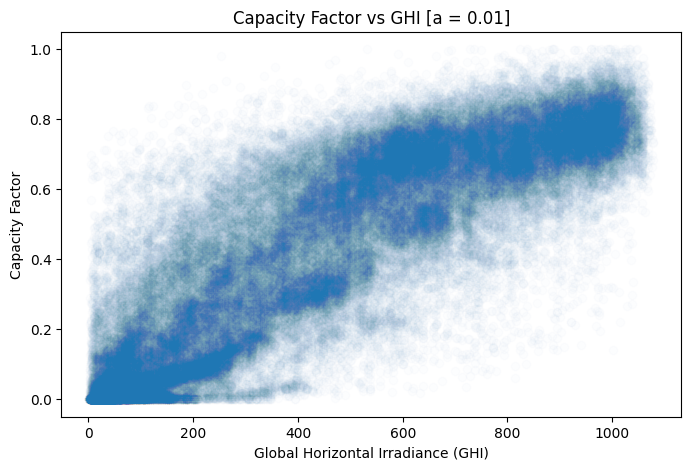

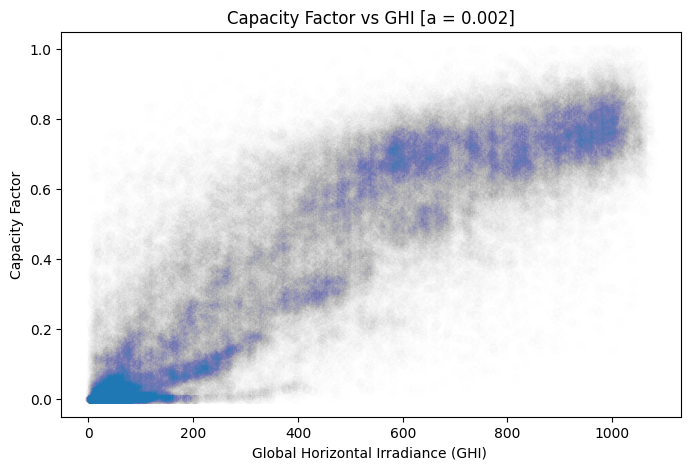

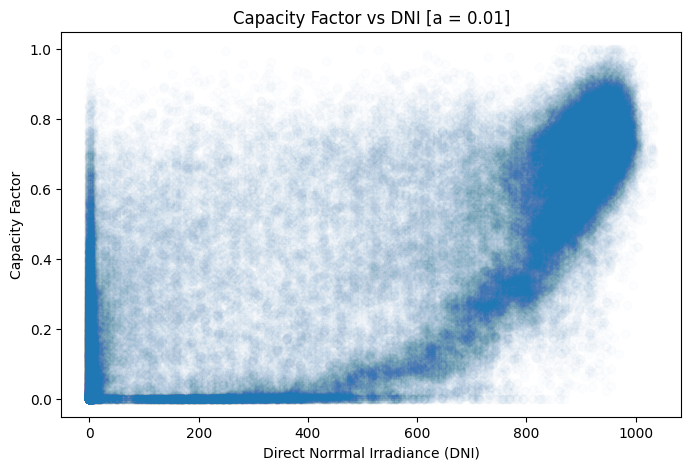

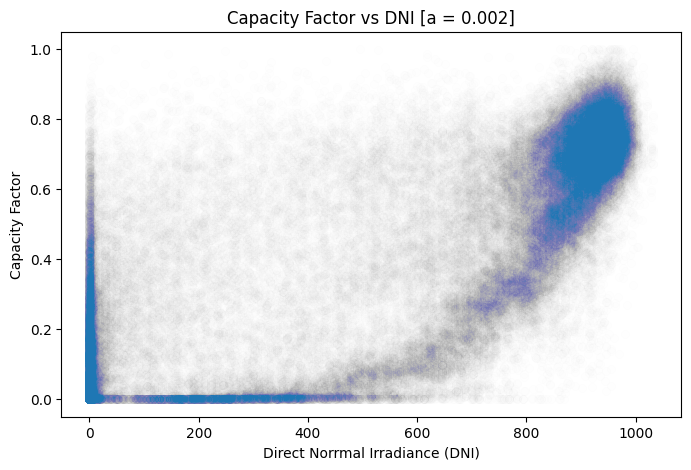

,cf,GHI,DNI,cloud
cf,1.000000,0.840026,0.679542,-0.267769
GHI,0.840026,1.000000,0.765469,-0.316877
DNI,0.679542,0.765469,1.000000,-0.670247
cloud,-0.267769,-0.316877,-0.670247,1.000000


In [66]:
# GHI
plt.figure(figsize=(8, 5))

plt.scatter(
    df['GHI'],
    df['cf'],
    alpha=0.01
)

plt.xlabel('Global Horizontal Irradiance (GHI)')
plt.ylabel('Capacity Factor')
plt.title('Capacity Factor vs GHI [a = 0.01]')
plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    df['GHI'],
    df['cf'],
    alpha=0.002
)

plt.xlabel('Global Horizontal Irradiance (GHI) ')
plt.ylabel('Capacity Factor')
plt.title('Capacity Factor vs GHI [a = 0.002]')
plt.show()

# DNI
plt.figure(figsize=(8, 5))

plt.scatter(
    df['DNI'],
    df['cf'],
    alpha=0.01
)

plt.xlabel('Direct Norrmal Irradiance (DNI)')
plt.ylabel('Capacity Factor')
plt.title('Capacity Factor vs DNI [a = 0.01]')
plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    df['DNI'],
    df['cf'],
    alpha=0.002
)

plt.xlabel('Direct Norrmal Irradiance (DNI)')
plt.ylabel('Capacity Factor')
plt.title('Capacity Factor vs DNI [a = 0.002]')
plt.show()

df[['cf', 'GHI', 'DNI', 'cloud']].corr()

- GHI correlates positively with capacity factor at +0.84, and is visible from the upwards trend from the scatterplots
- When a = 0.002 (both), the values close to 0 still appear dense, which matches the earlier claim where a lot of values must be close to 0
- When a = 0.002 (GHI), some parts on top are quite dense where as the middle part are much more sparser

### Pearson and Spearman correlation

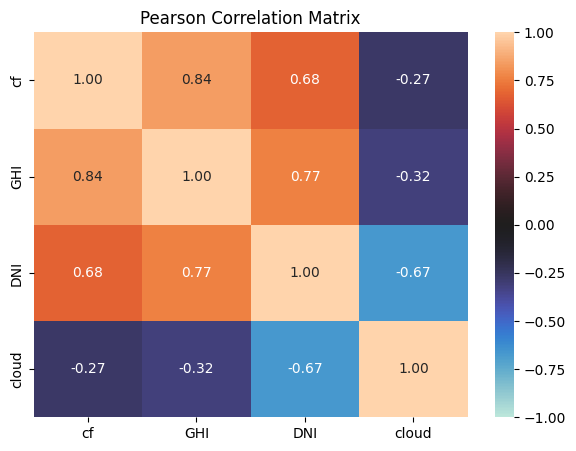

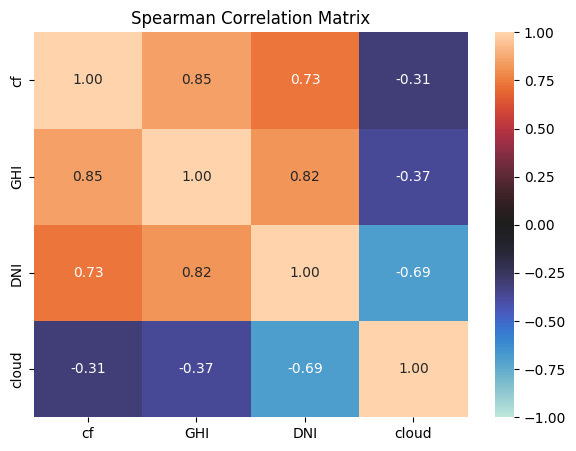

In [54]:
corr_vars = ['cf', 'GHI', 'DNI', 'cloud']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

plt.figure(figsize=(7, 5))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Pearson Correlation Matrix')
plt.show()

plt.figure(figsize=(7, 5))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Spearman Correlation Matrix')
plt.show()

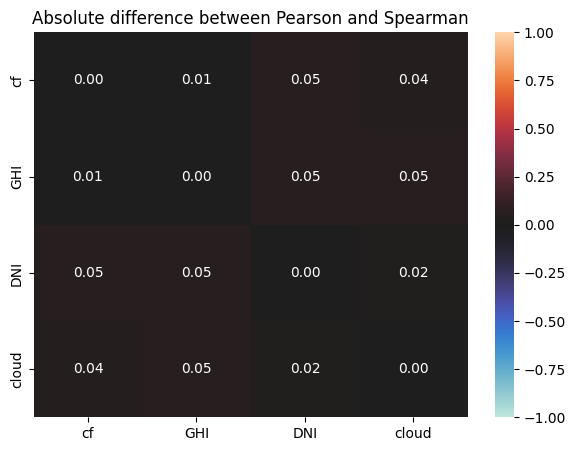

In [55]:
corr_delta = pearson_corr - spearman_corr
corr_abs_delta = corr_delta.abs()

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_abs_delta,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Absolute difference between Pearson and Spearman')
plt.show()

- Pearson and Spearman correlation are very similar for all values as the different is at most 0.05
- GHI and DNI has a strong positive correlation with capacity factor at approximately +0.85 and +0.73 (Spearman) respectively
- Cloud has a significant negative correlation with capacity factor at approximately -0.31 (Spearman)
- It is very possible that this high correlation is because most of the dataset has cf near 0 when GHI and DNI are also near 0

In [68]:
thresholds = [0, 10, 25, 50, 100]

results = []

for threshold in thresholds:
    subset = df[df['GHI'] > threshold]

    pearson = subset['GHI'].corr(subset['cf'], method='pearson')
    spearman = subset['GHI'].corr(subset['cf'], method='spearman')

    results.append({
        'GHI threshold': threshold,
        'Observations': len(subset),
        'Pearson': pearson,
        'Spearman': spearman,
        'Abs difference': abs(pearson - spearman)
    })

threshold_results = pd.DataFrame(results)

display(threshold_results.round(3))

results = []

for threshold in thresholds:
    subset = df[df['DNI'] > threshold]

    pearson = subset['DNI'].corr(subset['cf'], method='pearson')
    spearman = subset['DNI'].corr(subset['cf'], method='spearman')

    results.append({
        'DNI threshold': threshold,
        'Observations': len(subset),
        'Pearson': pearson,
        'Spearman': spearman,
        'Abs difference': abs(pearson - spearman)
    })

threshold_results = pd.DataFrame(results)

display(threshold_results.round(3))

,GHI threshold,Observations,Pearson,Spearman,Abs difference
0,0,87302,0.840,0.847,0.007
1,10,86350,0.837,0.843,0.006
2,25,83437,0.825,0.831,0.006
3,50,79362,0.804,0.811,0.006
4,100,73369,0.770,0.779,0.009


,DNI threshold,Observations,Pearson,Spearman,Abs difference
0,0,81787,0.658,0.713,0.055
1,10,77050,0.643,0.702,0.059
2,25,75540,0.640,0.698,0.058
3,50,74053,0.643,0.696,0.053
4,100,72031,0.654,0.697,0.043


- Both Pearson and Spearman correlations of GHI went down by approximately 0.07 from observations at threshold 0 against threshold 100
- DNI threshold's effect on the correlations are negligible

### Check if the correlations exist within individual plants

In [71]:
# Compare each plant's correlation with the overall dataset correlation

variables = ['GHI', 'DNI', 'cloud']

# Overall Spearman correlations
overall_corr = {
    variable: df[variable].corr(df['cf'], method='spearman')
    for variable in variables
}

# Plant-specific correlations
results = []

for plant, group in df.groupby('plant'):

    row = {
        'Plant': plant,
        'Observations': len(group)
    }

    for variable in variables:
        plant_corr = group[variable].corr(group['cf'], method='spearman')

        row[f'{variable} Spearman'] = plant_corr
        row[f'{variable} |Difference|'] = abs(
            overall_corr[variable] - plant_corr
        )

    results.append(row)

plant_corr = pd.DataFrame(results)

# Add the overall correlation as the first row
overall_row = {
    'Plant': 'Overall',
    'Observations': len(df)
}

for variable in variables:
    overall_row[f'{variable} Spearman'] = overall_corr[variable]
    overall_row[f'{variable} |Difference|'] = 0

plant_corr = pd.concat(
    [pd.DataFrame([overall_row]), plant_corr],
    ignore_index=True
)

display(plant_corr.round(3))

,Plant,Observations,GHI Spearman,GHI |Difference|,DNI Spearman,DNI |Difference|,cloud Spearman,cloud |Difference|
0,Overall,87302,0.847,0.000,0.727,0.000,-0.309,0.000
1,Actual_32.75_-115.45_2006_UPV_,4329,0.671,0.176,0.638,0.090,-0.276,0.033
2,Actual_33.05_-116.85_2006_DPV_,4375,0.893,0.047,0.725,0.003,-0.285,0.024
3,Actual_33.25_-114.85_2006_UPV_,4329,0.768,0.078,0.684,0.043,-0.255,0.054
4,Actual_33.65_-117.25_2006_DPV_,4375,0.909,0.063,0.772,0.045,-0.339,0.030
5,Actual_33.75_-116.15_2006_UPV_,4363,0.814,0.033,0.750,0.023,-0.263,0.046
6,Actual_33.75_-116.25_2006_DPV_,4363,0.900,0.053,0.769,0.042,-0.160,0.149
7,Actual_34.05_-117.15_2006_DPV_,4375,0.900,0.053,0.743,0.016,-0.266,0.043
8,Actual_34.15_-117.25_2006_DPV_,4375,0.909,0.063,0.755,0.028,-0.279,0.030
9,Actual_34.25_-117.65_2006_UPV_,4375,0.886,0.039,0.741,0.014,-0.269,0.040


- Most plants seem to have its specific correlations be around the overall correlation
- Some plants correlate better/worse with certain attribute (Plant 1's GHI, Plant 16's Cloud)

### Check for season

,count,mean,median,std
season,,,,
Autumn,20205,0.456431,0.512701,0.268315
Spring,23584,0.435901,0.445687,0.297721
Summer,25395,0.453411,0.514401,0.279141
Winter,18118,0.413165,0.444914,0.266189


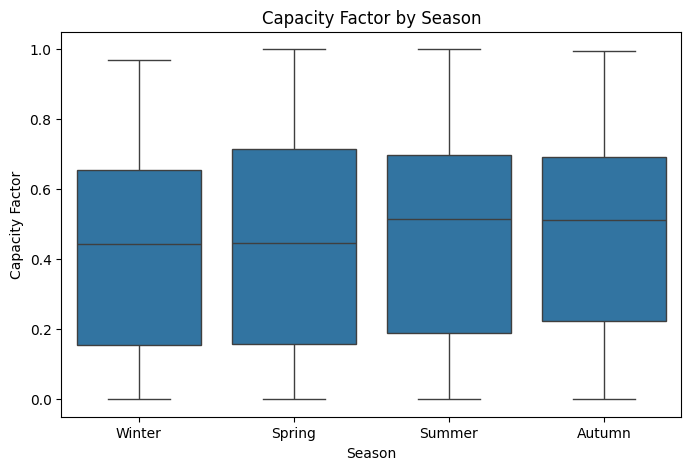

In [73]:
season_summary = (
    df.groupby('season')['cf']
      .agg(['count', 'mean', 'median', 'std'])
)

display(season_summary)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='season',
    y='cf'
)

plt.xlabel('Season')
plt.ylabel('Capacity Factor')
plt.title('Capacity Factor by Season')
plt.show()

- Median of Summer and Autumn are significantly higher than Winter and Spring by approximately 0.06


season,Autumn,Spring,Summer,Winter
plant,,,,
Actual_32.75_-115.45_2006_UPV_,0.565248,0.581649,0.514826,0.537382
Actual_33.05_-116.85_2006_DPV_,0.461501,0.417867,0.429545,0.454629
Actual_33.25_-114.85_2006_UPV_,0.483941,0.480318,0.418659,0.494802
Actual_33.65_-117.25_2006_DPV_,0.438656,0.401827,0.421220,0.423729
Actual_33.75_-116.15_2006_UPV_,0.576700,0.592653,0.542994,0.562835
Actual_33.75_-116.25_2006_DPV_,0.461496,0.473673,0.424109,0.466180
Actual_34.05_-117.15_2006_DPV_,0.436345,0.389006,0.423983,0.414397
Actual_34.15_-117.25_2006_DPV_,0.419555,0.379741,0.415107,0.398392
Actual_34.25_-117.65_2006_UPV_,0.441488,0.386250,0.417768,0.419926


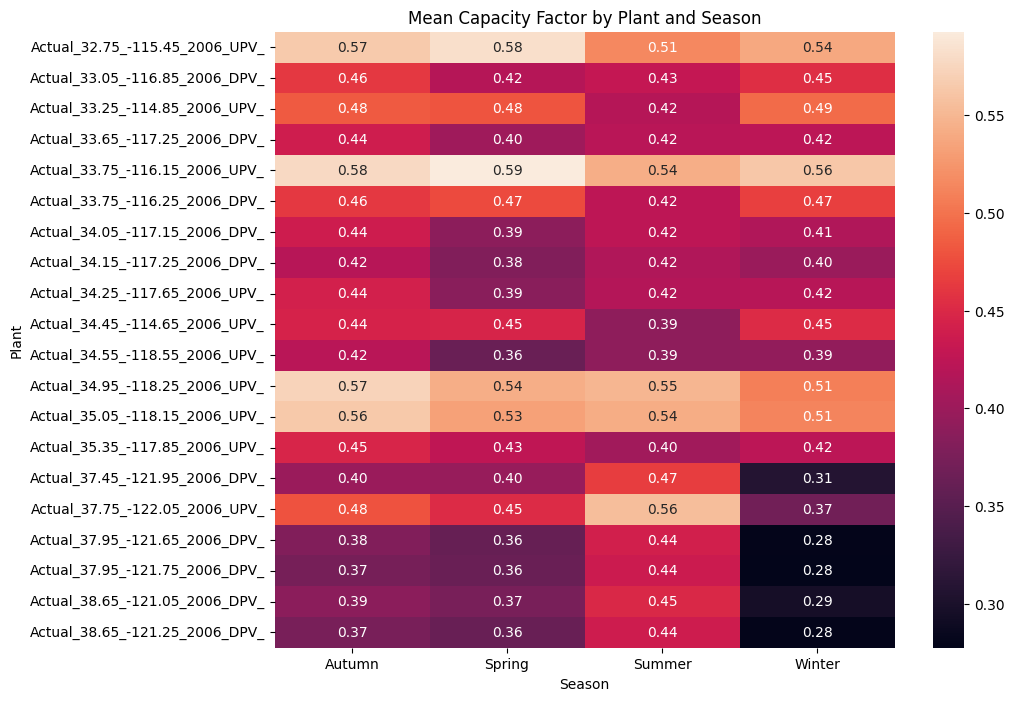

In [74]:
season_plant = (
    df.groupby(['plant', 'season'])['cf']
      .mean()
      .unstack()
)

display(season_plant)

plt.figure(figsize=(10, 8))

sns.heatmap(
    season_plant,
    annot=True,
    fmt='.2f'
)

plt.title('Mean Capacity Factor by Plant and Season')
plt.xlabel('Season')
plt.ylabel('Plant')
plt.show()

- Some plants don't change much between season, some change significantly

### Correlation with time of day

hour
5     0.027542
6     0.134354
7     0.266425
8     0.451974
9     0.577701
10    0.652036
11    0.685908
12    0.679141
13    0.634151
14    0.552996
15    0.409880
16    0.211132
17    0.096825
18    0.015441
19    0.000000
Name: cf, dtype: float64

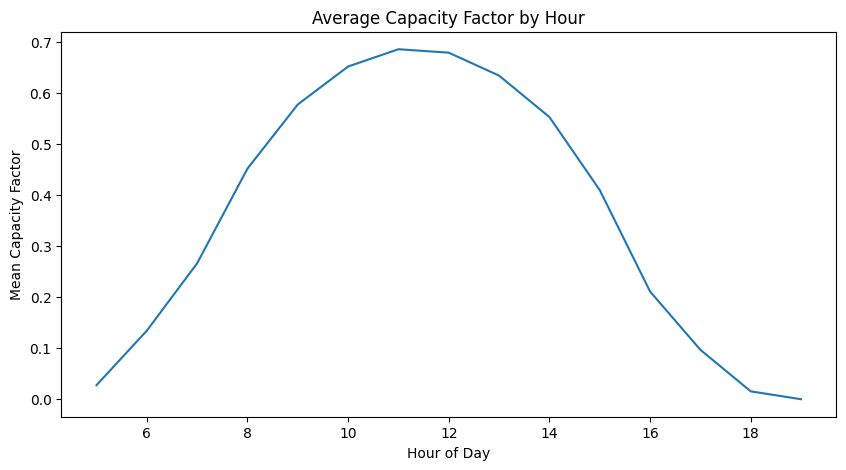

In [78]:
hourly_cf = (
    df.groupby('hour')['cf']
      .mean()
)

display(hourly_cf)

hourly_cf.plot(figsize=(10, 5))

plt.xlabel('Hour of Day')
plt.ylabel('Mean Capacity Factor')
plt.title('Average Capacity Factor by Hour')
plt.show()

- As expected, capacity factor is at its maximum at noon, and becomes gradually smaller before noon and past noon

,mean,median,std,count
GHI_bin,,,,
"(1.999, 56.0]",0.048614,0.004669,0.097290,8743
"(56.0, 140.0]",0.127467,0.074118,0.146112,8749
"(140.0, 240.0]",0.226285,0.190681,0.169637,8785
"(240.0, 347.0]",0.323123,0.303985,0.182806,8649
"(347.0, 455.0]",0.433099,0.432349,0.174474,8753
"(455.0, 556.0]",0.525155,0.552309,0.166706,8735
"(556.0, 656.0]",0.608539,0.641293,0.147376,8770
"(656.0, 778.0]",0.649474,0.675068,0.140012,8714
"(778.0, 910.0]",0.708726,0.720536,0.118506,8737


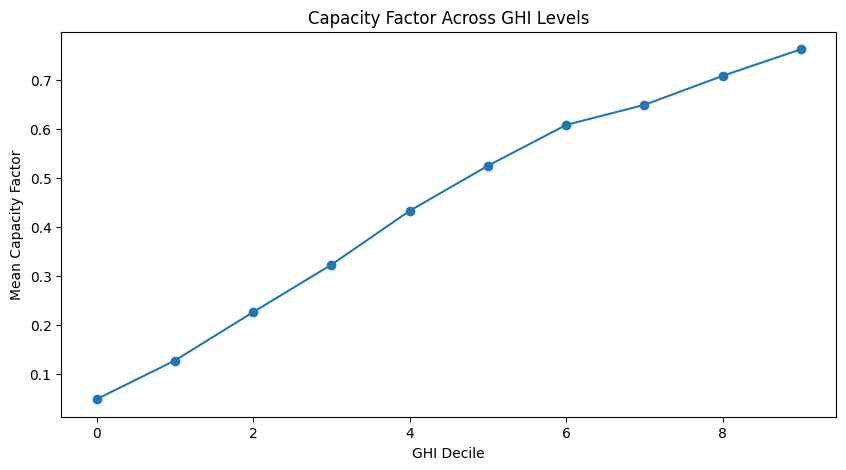

,mean,median,std,count
DNI_bin,,,,
"(-0.001, 4.0]",0.161998,0.099702,0.184488,8846
"(4.0, 157.0]",0.239342,0.195717,0.213084,8660
"(157.0, 380.0]",0.235510,0.135680,0.253133,8686
"(380.0, 582.0]",0.284476,0.202524,0.255781,8739
"(582.0, 719.0]",0.350885,0.298358,0.228208,8735
"(719.0, 815.0]",0.454969,0.435107,0.183642,8810
"(815.0, 871.0]",0.573847,0.581604,0.158762,8646
"(871.0, 911.0]",0.659968,0.675440,0.131173,8738
"(911.0, 944.0]",0.707636,0.716752,0.115980,8799


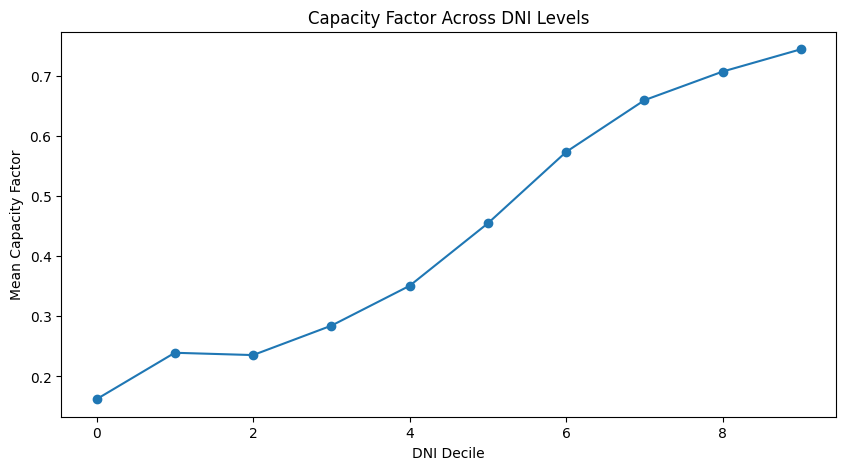

In [81]:
df['GHI_bin'] = pd.qcut(
    df['GHI'],
    q=10,
    duplicates='drop'
)

ghi_summary = (
    df.groupby('GHI_bin', observed=True)['cf']
            .agg(['mean', 'median', 'std', 'count'])
)

display(ghi_summary)

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(ghi_summary)),
    ghi_summary['mean'],
    marker='o'
)

plt.xlabel('GHI Decile')
plt.ylabel('Mean Capacity Factor')
plt.title('Capacity Factor Across GHI Levels')
plt.show()

df['DNI_bin'] = pd.qcut(
    df['DNI'],
    q=10,
    duplicates='drop'
)

dni_summary = (
    df.groupby('DNI_bin', observed=True)['cf']
            .agg(['mean', 'median', 'std', 'count'])
)

display(dni_summary)

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(dni_summary)),
    dni_summary['mean'],
    marker='o'
)

plt.xlabel('DNI Decile')
plt.ylabel('Mean Capacity Factor')
plt.title('Capacity Factor Across DNI Levels')
plt.show()

# It's not a numerical column
# df['cloud_bin'] = pd.qcut(
#     df['cloud'],
#     q=10,
#     duplicates='drop'
# )

# cloud_summary = (
#     df.groupby('cloud_bin', observed=True)['cf']
#             .agg(['mean', 'median', 'std', 'count'])
# )

# display(cloud_summary)

# plt.figure(figsize=(10, 5))

# plt.plot(
#     range(len(cloud_summary)),
#     cloud_summary['mean'],
#     marker='o'
# )

# plt.xlabel('Cloud Type Decile')
# plt.ylabel('Mean Capacity Factor')
# plt.title('Capacity Factor Across Cloud Type')
# plt.show()

- Capacity factor increases roughly linearly with each GHI or DNI decile

In [83]:
groups = [
    df.loc[df['season'] == season, 'cf']
    for season in ['Winter', 'Spring', 'Summer', 'Autumn']
]

result = f_oneway(*groups)

print(result)

F_onewayResult(statistic=np.float64(99.9125699098207), pvalue=np.float64(1.4631154176823628e-64))


- Because p-value is very small, seasonal difference matters